# Does the "three-inside-up" candle pattern flip the trend? 🕯️
### A textbook three-candle reversal — down bar, inside harami, a confirming candle — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Confirmation_adds_edge%3F: Busted](https://img.shields.io/badge/Confirmation_adds_edge%3F-Busted-8b949e?style=flat-square)

Open any candlestick book and you'll meet the **three-inside-up**: a down candle, then a small **inside** candle tucked inside it (a *harami*), then a third **confirmation** candle that closes back up past the first. The lore — from Nison and every chart-pattern site — is that this triplet **flips the trend**: the confirming candle says "the down-move is over, buy." The whole appeal is that *third* candle: it's supposed to be the proof.

It *looks* convincing on a hand-picked chart. But a pattern you spot **after** the bars have printed is the textbook way to fool yourself. So we did the only fair thing: encode the pattern **mechanically** (no eyeballing), fire it across five big indices over 21 years, and time the result — against the baseline that matters (**buying on random days**) and against the **same pattern with the confirming candle removed**.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from three_inside import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real three-inside cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 64, 'tl': 5, 'fp_spy': '4cb5244f3990', 'h5': (5, 64, 30.4, 61, 1.22, 10.3, 20.1, 28.4, 0.63, 0.528), 'h10': (10, 64, 10.3, 62, 0.25, 53.6, -43.2, 8.3, -0.86, 0.392), 'h20': (20, 64, -106.9, 47, -1.61, 33.1, -139.9, -108.9, -1.75, 0.083), 'h60': (60, 64, -13.3, 48, -0.12, 118.9, -132.3, -15.3, -1.04, 0.302), 'per': [('SPY', 11, -177.4, -1.08, 39.3, -216.7), ('QQQ', 14, -136.3, -0.62, 88.2, -224.5), ('IWM', 18, -107.6, -1.21, 2.7, -110.3), ('DIA', 11, -93.3, -0.97, 33.7, -127.0), ('GLD', 10, -1.6, -0.01, 1.5, -3.1)], 'placebo': (64, -106.9, 211, 91.4, -198.3, -2.49, 0.015), 'syn': [(0.0, 20, -87.1, 45, -1.18), (0.6, 20, 341.6, 75, 4.43)]}


real three-inside cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when a three-inside-up confirms, do I make money? | **No, on average you *lose*.** Over 20 days the pattern averages **−107 bps** — the "bullish reversal" is typically followed by a *drop*. |
| Does it beat buying on **random days**? | **No.** Random-day entries make **+33 bps** over the same 20 days; the pattern is **140 bps worse** than throwing darts. |
| Does the famous **confirmation candle** add anything? | **It makes it worse.** Drop the third candle and just buy the bare harami → **+91 bps**. The confirmation candle *subtracts* ~198 bps. |
| So is it a tradable edge? | **No.** It's a rare pattern (64 signals in 21 years) that loses to a coin flip and whose celebrated "proof" candle is the worst part. |

> The three-inside-up is a tidy way to *label* a wiggle after the fact. As a *forecast* — "the trend will flip up" — it's a **mirage**, and the confirming candle (the bit everyone trusts) actively hurts.

## 1 · The claim

> *"After a downtrend: a down candle (A), then a small candle that fits **inside** A's body (B, the harami), then a third candle (C) that closes back **above A's open** — that confirms the reversal. Go long. The mirror three-inside-down is the sell at a top."*

This is a **confirmed harami**, popularised by **Steve Nison** and catalogued by **Gregory Morris** — one of the most-taught three-candle reversals in technical analysis, built into every charting suite's pattern scanner. The distinguishing feature versus the bare two-candle harami is the **confirmation candle**. So the real question is: does that third candle earn its keep?

## 2 · So what?

If the three-inside-up genuinely *forecast* reversals, it would be remarkable: three past candles predicting a turning point, a clean edge you could scan for. That's the dream the pattern sells.

But there are two traps. First, it's spotted **after** the candles print on a market that drifts **up**, so *any* long rule looks okay by default — we must compare to buying on **random days**. Second, the pattern's selling point is the **confirmation candle**, and the honest way to test it is to **remove it**: fire on the bare harami and see whether the third candle added or destroyed edge. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Detect the pattern by rule.** A is a down candle after a 5-day downtrend; B's whole range sits inside A's body (a strict harami); C closes back above A's open and above B's close. All read on **closed** bars — no peeking ahead.
2. **Trade the lore.** On the confirming candle's close, buy at the **next** close; measure the return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the same hold on **random days**. If the pattern matters, it must beat random.
4. **The confirmation test.** Re-run with the **confirmation candle removed** (buy the bare harami). If the third candle adds edge, the confirmed version must win. *If it doesn't, the celebrated confirmation is busted* — announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical three-inside-up even look like? Here's SPY with the confirmed buy signals the rule fires.

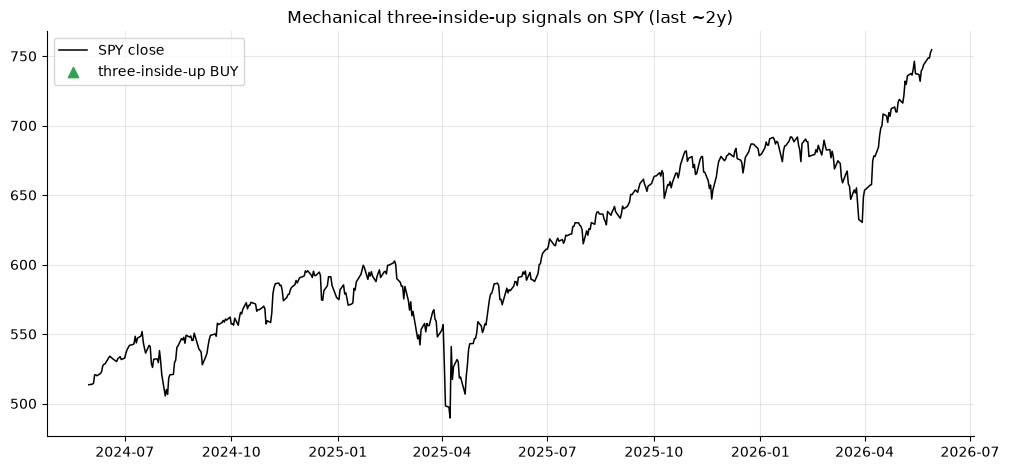

confirmed signals in window: 0


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    seg = b.iloc[-500:]
    ent = st.three_inside_entries(b, trend_lookback=R['tl'], require_confirm=True)
    ent = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg['close'].values, c='k', lw=1.1, label='SPY close')
    ax.scatter(ent, b['close'].reindex(ent), c=GREEN, s=55, zorder=5, marker='^', label='three-inside-up BUY')
    ax.set_title('Mechanical three-inside-up signals on SPY (last ~2y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('confirmed signals in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The signals are rare and land on small bounces. The question is whether those green arrows are followed by sustained up-moves. **Let's race the confirmed pattern against random entries** at four horizons. Blue = the three-inside-up; grey = buy on random days.

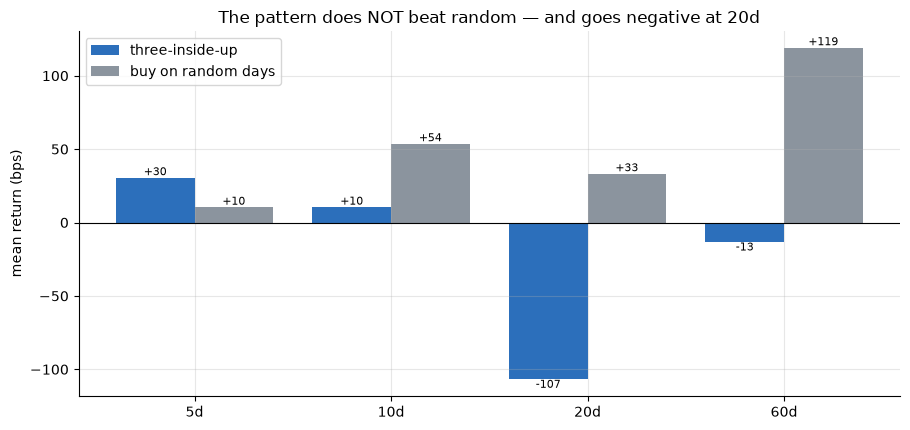

confirmed: [30, 10, -107, -13]
random: [10, 54, 33, 119]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    conf, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.three_inside_entries(bb, trend_lookback=R['tl'], require_confirm=True)
            re = st.random_entries(c, max(len(e),50), seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        conf.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    conf = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, conf, .4, color='#2c6fbb', label='three-inside-up')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
ax.axhline(0, c='k', lw=.8)
for i,(a,bb) in enumerate(zip(conf,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom' if a>=0 else 'top',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom' if bb>=0 else 'top',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The pattern does NOT beat random — and goes negative at 20d'); ax.legend()
plt.tight_layout(); plt.show()
print('confirmed:', [round(v) for v in conf]); print('random:', [round(v) for v in rnd])

There's the story. The "bullish reversal" makes money only at 5 days (**+30 bps**), then turns **negative at 20 days** (**-107 bps**) — the down-move is, on average, *not* over. And random entries do better at 10/20/60 days. The pattern doesn't beat a dart.

**The key test.** What if we **remove the confirmation candle** — buy the bare harami instead? If the famous third candle adds edge, the confirmed version should win.

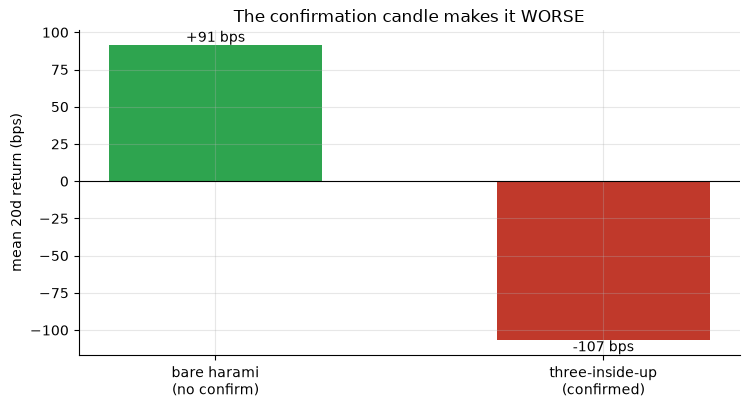

bare harami: +91 bps   confirmed: -107 bps   confirmation adds -198 bps


In [4]:
if HAVE_REAL:
    cf, hr = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t); c = bb['close']
        ec = st.three_inside_entries(bb, trend_lookback=R['tl'], require_confirm=True)
        eh = st.three_inside_entries(bb, trend_lookback=R['tl'], require_confirm=False)
        cf.append(st.forward_returns(c, ec, 20)); hr.append(st.forward_returns(c, eh, 20))
    conf_m = np.concatenate(cf).mean()*1e4; har_m = np.concatenate(hr).mean()*1e4
else:
    conf_m = R['placebo'][1]; har_m = R['placebo'][3]
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar(['bare harami\n(no confirm)','three-inside-up\n(confirmed)'], [har_m, conf_m],
       color=[GREEN, RED], width=.55)
ax.axhline(0, c='k', lw=.8)
for i,v in enumerate([har_m, conf_m]): ax.annotate(f'{v:+.0f} bps',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_ylabel('mean 20d return (bps)'); ax.set_title('The confirmation candle makes it WORSE')
plt.tight_layout(); plt.show()
print(f'bare harami: {har_m:+.0f} bps   confirmed: {conf_m:+.0f} bps   confirmation adds {conf_m-har_m:+.0f} bps')

There it is. The bare harami averages **+91 bps**; adding the "confirming" candle drags it to **-107 bps** — a **-198 bps** swing the *wrong* way. The confirmation candle, the part the lore prizes most, is the worst part of the rule: it makes you buy *after* a one-day pop, i.e. chase.

## 5 · The verdict

- **Signal — None.** The confirmed three-inside-up does **not** beat buying on random days (it's worse at 10/20/60 days and goes negative at 20). There isn't even a drift mirage here — the "reversal" is, on average, followed by a fall.
- **Tradability — Mirage.** A rare pattern (64 signals in 21 years) that loses to a coin flip in every name; costs only deepen it.
- **"Does the confirmation candle add edge?" — Busted.** Removing the third candle *improves* the result by ~198 bps. The celebrated confirmation is a net negative.

## 6 · Could you actually trade it?

There's nothing here to trade. The pattern fires rarely, loses to a random-day entry, and its defining feature (the confirmation candle) actively hurts. If anything, the *bare* harami is the better idea — but even that is just a slow dip-buy that you'd capture more cheaply by holding the index. Costs on every signal push the already-negative result further down. As a forecasting tool, the three-inside-up doesn't pay.

## 7 · Going further 🚪

- **The bare harami.** It beat the confirmed version here — a fun follow-up is to test the two-candle harami on its own terms (it's still no edge vs random, but it's *less* bad).
- **The mirror three-inside-down.** The bearish version at tops inherits the same problem in reverse — confirmation = chasing.
- **A real positive control.** The quants notebook plants a *genuine* three-inside-up bounce into a synthetic tape and shows the harness banks it (so the flat real-tape result isn't a dead detector — it's an honest 'nothing there').

*Think the confirmation candle forecasts? Show the confirmed three-inside-up beating both random entries **and** the bare harami at **t ≥ 2** on a real tape — then we'll talk.*